<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Pca_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Principal Component Analysis (PCA)**

**Principal Component Analysis (PCA)** is a **dimensionality reduction technique**. The core idea is to transform your data into a new coordinate system where the axes (called principal components) capture the most variance. The **first principal component accounts for the largest variance**, the second for the next largest, and so forth. *By selecting only the top principal components, you reduce dimensions while retaining as much information as possible*.

# **Source:** https://www.youtube.com/watch?v=FgakZw6K1QQ&t=448s

**Key points for quick navigation:**

00:00 PCA SVD introduction

00:33 Genes mice dataset

01:04 One gene line

01:37 Two genes clustering

02:15 Three genes 3D

02:53 PCA dimensional reduction

03:32 Center data origin

04:06 Shift center origin

04:41 Fit line origin

05:16 Project measure distances

05:46 Maximize projected distances

06:54 Pythagorean inverse relation

07:25 Maximize squared distances

09:02 PC1 best line

09:36 PC1 slope recipe

10:14 Linear combination variables

11:16 Scale unit vector

12:23 Eigenvector loading scores

12:57 PC2 perpendicular PC1

14:24 Project samples plot

14:52 Eigenvalues variation measure

15:44 Variation proportions PCs

16:14 Scree plot variation

16:44 3D PCA process

18:22 Scree plot proportions

19:40 2D approximation good

20:03 High-D PCA works

20:58 Clusters despite noise

*Made with HARPA AI*

In [110]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # import PCA from sklearn.decomposition
import matplotlib.pyplot as plt

### **1. Load Dataset**

```python
data = load_iris()
X = data.data
```

* `X` has **150 samples × 4 features**
* Features = sepal length, sepal width, petal length, petal width

---

In [111]:
# Load the Iris dataset
data = load_iris()
X = data.data

### **2. Standardization** (VERY IMPORTANT)

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

Why?

* PCA is **variance-based**
* Features with larger scale dominate

So we transform:
[
X_{scaled} = \frac{X - \mu}{\sigma}
]

Now all features have:

* mean = 0
* std = 1

---

In [112]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **3. PCA Transformation**

```python
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
```

What PCA does internally:

1. Compute covariance matrix
2. Find eigenvectors & eigenvalues
3. Sort by highest variance
4. Project data onto top directions

You reduce:

```
4D → 2D
```

---

The core mechanism is to calculate the **covariance matrix** of your data and then perform an **eigen-decomposition**. The eigenvectors of that covariance matrix are the **principal components**. You *order them by their eigenvalues*, which indicate h*ow much variance each component explains*. After projecting the data onto these top components, **you get a lower-dimensional representation with minimal information loss**.

In [113]:
# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
# pca = PCA(n_components=0.95)  # adaptive
X_pca = pca.fit_transform(X_scaled)

---

# What is `n_components`?

`n_components` = **how many principal directions (PCs) you want to keep**

* `2` → keep top 2 most important directions
* `1` → compress data to 1D
* `< original_dim` → dimensionality reduction

---

# Default value in `sklearn`

```python
PCA()
```

👉 Default:

```python
n_components = None
```

Meaning:

> Keep **all components** (= original number of features)

So if your data is `(n_samples, 2)` → PCA keeps 2 components anyway.

---

# Then why did you write `n_components=2`?

In your case:

* Original data = 2D
* So:

```python
n_components=2
```

* does **NOT reduce anything**

* only **rotates the coordinate system**

---


> “`n_components` controls how many principal axes we retain. It is chosen based on explained variance so that we preserve most of the information while reducing dimensionality.”


* Default → `None` → keep all features
* `2` → keep top 2 PCs
* Choose using → **explained variance (95% rule)**
* In your example → `2` = just rotation, no compression

---

### **4. Visualization**

```python
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target)
```

* X-axis = **Principal Component 1 (PC1)**
* Y-axis = **Principal Component 2 (PC2)**
* Colors = 3 species

---

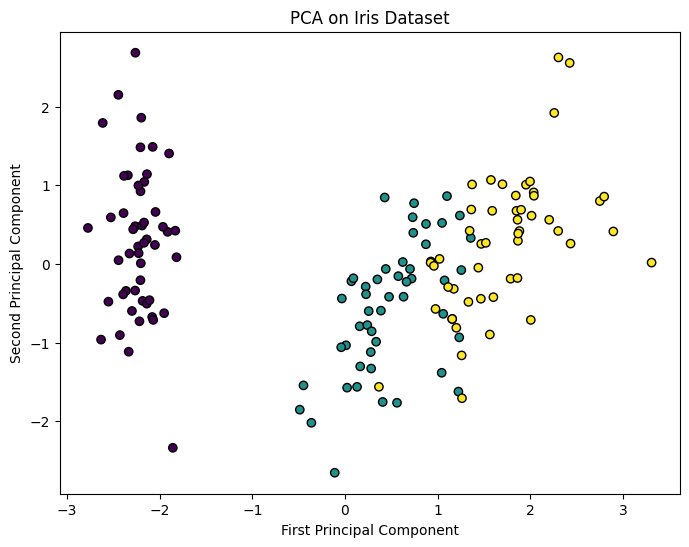

In [114]:
# Plot the two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='viridis', edgecolor='k')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA on Iris Dataset')
plt.show()

---

## **What Your Plot Means**

### Key Observations:

### 1. Left cluster (clearly separated)

* This is **Setosa**
* Very distinct → easy to classify

### 2. Right side (two overlapping clusters)

* **Versicolor + Virginica**
* They overlap → harder to separate

---

## Why PCA Works Here

Because features are **correlated**:

* Petal length & width carry strong signal
* PCA combines them into **better axes**

Instead of:

```
(sepal_length, sepal_width, petal_length, petal_width)
```

You now have:

```
PC1 = best direction (max variance)
PC2 = second best direction
```

---

## Production-Level Insight

### When to use PCA:

* Reduce dimensionality
* Remove multicollinearity
* Speed up models
* Visualization

### When NOT to:

* When interpretability matters (features lose meaning)
* Tree-based models (they don’t need it)

---

In [115]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762]
0.9581320720000166


## How Much Information You Kept

👉 Meaning:

* PC1 = ~72% variance
* PC2 = ~23%
* Total = **95% information retained**

So:

> You compressed 4D → 2D with almost no loss




---



## **Final Intuition**

Think of PCA like:

> “Rotate the data so that the most important information becomes visible in fewer dimensions.”

---


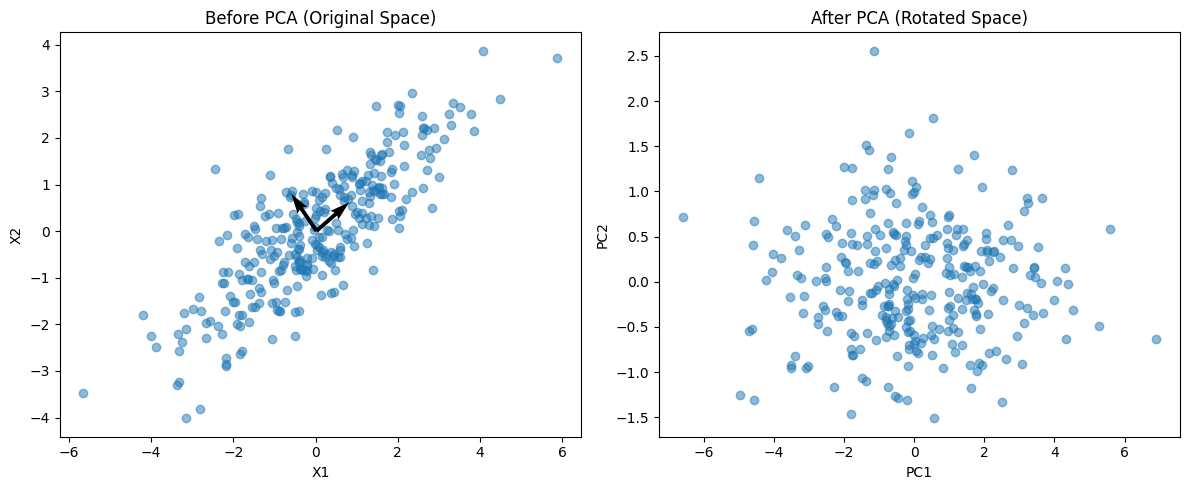

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Generate correlated data
np.random.seed(42)

mean = [0, 0]
cov = [[3, 2], [2, 2]]   # correlated features → tilted ellipse

X = np.random.multivariate_normal(mean, cov, 300)

# 2. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Eigenvectors (principal directions)
components = pca.components_

# 3. Plot
plt.figure(figsize=(12, 5))

# BEFORE PCA
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.title("Before PCA (Original Space)")
plt.xlabel("X1")
plt.ylabel("X2")

# Draw eigenvectors
origin = np.mean(X, axis=0)
for vec in components:
    plt.quiver(origin[0], origin[1],
                   vec[0], vec[1],
                                  angles='xy', scale_units='xy', scale=1)

# AFTER PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title("After PCA (Rotated Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


> “PCA finds the direction where data varies the most, then rotates the coordinate system so that direction becomes the new X-axis.”

---

# One subtle but important insight

In your **right plot**, data looks more “circular” vertically:

* PC1 → captures most variance
* PC2 → much smaller variance

👉 That’s why dimensionality reduction works:
You can drop PC2 and still keep most information.

---


Think of PCA as:

> “Rotating the camera so the data looks straight instead of tilted.”

---



In [117]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
X = load_iris().data

# Standardize
X = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Variance captured:", pca.explained_variance_ratio_)

Variance captured: [0.72962445 0.22850762]




---



In [118]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [119]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df.head()

,Height,Weight,Age,Gender
0,170,65,30,1
1,165,59,25,0
2,180,75,35,1
3,175,68,28,1
4,160,55,22,0


In [128]:
df.cov()

,Height,Weight,Age,Gender
Height,55.344444,55.444444,33.566667,3.388889
Weight,55.444444,57.777778,35.333333,3.555556
Age,33.566667,35.333333,22.677778,2.166667
Gender,3.388889,3.555556,2.166667,0.277778


In [121]:
X = df.drop('Gender', axis=1) # features (everything expect Gender)
y = df['Gender'] # Target (only Gender)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [122]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model_pca = LogisticRegression()
model_pca.fit(X_train, y_train)

y_pred = model_pca.predict(X_test)

print(pca.explained_variance_ratio_)


# accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

[0.97871061 0.01755646]
1.0


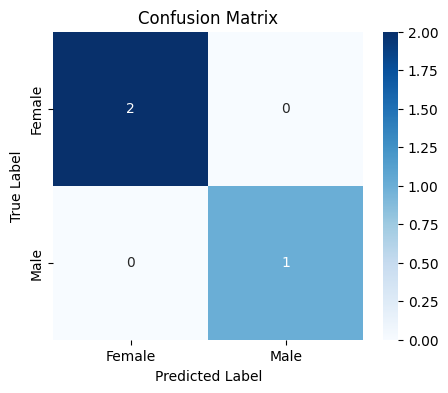

In [123]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [124]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

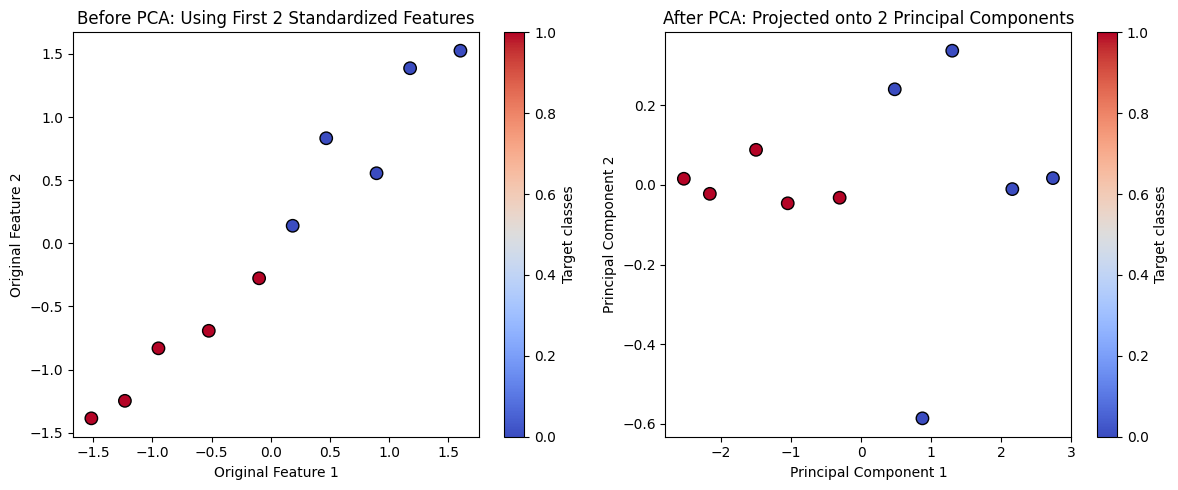

In [125]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

1.0


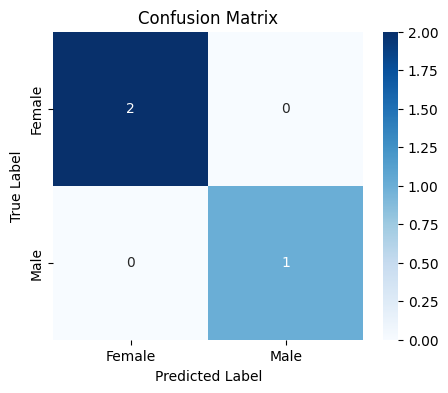

In [127]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Reference:** https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

---

# **Principal Component Analysis (PCA)**

## ✅ Advantages

1. **Handles Multicollinearity**
   Converts correlated features into a set of uncorrelated principal components.

2. **Dimensionality Reduction**
   Reduces the number of features while retaining most of the variance.

3. **Noise Reduction**
   Low-variance components (often noise) can be removed, improving data quality.

4. **Improves Model Performance**
   Reduces overfitting and speeds up training for many ML algorithms.

5. **Data Compression**
   Stores data efficiently using fewer components.

6. **Visualization**
   Enables projection of high-dimensional data into 2D/3D for analysis.

---

## ❌ Disadvantages

1. **Loss of Interpretability**
   Principal components are linear combinations of original features and are hard to interpret.

2. **Information Loss**
   Important information may be lost if too few components are retained.

3. **Sensitive to Scaling**
   Requires normalization/standardization before applying PCA.

4. **Assumes Linearity**
   Captures only linear relationships; fails on complex non-linear patterns.

5. **Computational Cost**
   Can be expensive for very large datasets (due to eigen decomposition/SVD).

6. **Not Always Useful**
   If features are already independent, PCA provides little benefit.

---

## 📌 Applications

1. **Machine Learning Preprocessing**
   Used to reduce feature space before training models (SVM, Logistic Regression, K-Means).

2. **Data Visualization**
   Projects high-dimensional datasets into 2D/3D for pattern recognition and clustering.

3. **Image Compression & Recognition**
   Used in face recognition (Eigenfaces) and reducing image storage size.

4. **Noise Reduction / Signal Processing**
   Removes noise from signals like audio, EEG, ECG.

5. **Finance (Risk Analysis)**
   Identifies underlying factors affecting stock prices and portfolios.

6. **Bioinformatics / Genomics**
   Analyzes gene expression data and clusters biological samples.

7. **Recommendation Systems (Indirectly)**
   Helps reduce dimensionality of user-item matrices and extract latent features.

---

## Summary

PCA transforms data into a new coordinate system where the **maximum variance lies along the first few axes**, enabling efficient compression and analysis.


In [139]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model_pca = LogisticRegression()
model_pca.fit(X_train, y_train)

y_pred = model_pca.predict(X_test)

print(pca.explained_variance_ratio_)


# accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

[0.97871061]
1.0


We are comparing two **different ways of specifying how much dimensionality reduction PCA should perform**:

---

# 🔹 1. `PCA(n_components=2)`

## ✅ Intuition

* You are **explicitly forcing** PCA to keep exactly **2 principal components**.
* Regardless of how much information (variance) is preserved, output will always be 2D.

👉 Think:

> “I want my data in 2D space — no matter what.”

## 📌 What it means mathematically

You keep the first 2 eigenvectors corresponding to the **top 2 eigenvalues (max variance directions)**.

---

## 👍 When to use

* Visualization (2D plots, scatter plots)
* When model requires fixed input size
* When you already know target dimension
* Teaching / debugging PCA

## ⚠️ Risk

* Might lose important information if 2 components don't capture enough variance

---

# 🔹 2. `PCA(n_components=0.95)`

## ✅ Intuition

* You are asking PCA:

  > “Keep enough components to preserve **95% of total variance**”

* PCA will **automatically decide number of components**.

👉 Output dimension is **not fixed** — depends on data.

---

## 📌 What it means mathematically

Find smallest `k` such that:

[
\frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{n} \lambda_i} \ge 0.95
]

Where:

* ( \lambda_i ) = eigenvalues (variance explained)

---

## 👍 When to use

* Real ML pipelines (production)
* Feature reduction without losing much information
* When you **don’t know optimal dimension**
* Preprocessing before models

## ⚠️ Tradeoff

* Output dimension varies → less control
* Might still keep more dimensions than expected

---

# 🔥 Key Difference (Core Idea)

| Aspect               | `n_components=2` | `n_components=0.95` |
| -------------------- | ---------------- | ------------------- |
| Type                 | Fixed dimension  | Variance-based      |
| Output size          | Always 2         | Data-dependent      |
| Control              | High (manual)    | Automatic           |
| Information retained | Unknown          | ~95% guaranteed     |
| Use case             | Visualization    | Real-world ML       |

---

# 🧠 Practical Insight (Important)

* If your goal is **understanding / plotting → use fixed (2 or 3)**
* If your goal is **performance / compression → use variance (0.90–0.99)**

---

# ⚡ Real Example

```python
from sklearn.decomposition import PCA

# Fixed dimension
pca_fixed = PCA(n_components=2)
X_2d = pca_fixed.fit_transform(X)

# Variance-based
pca_auto = PCA(n_components=0.95)
X_reduced = pca_auto.fit_transform(X)

print(X_2d.shape)        # (n_samples, 2)
print(X_reduced.shape)   # (n_samples, k) where k depends on data
```

---

# 🚀 Interview One-Liner

> `n_components=2` fixes output dimension, while `n_components=0.95` dynamically selects the minimum number of components needed to retain 95% variance.

---


